In [73]:
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

"""
Тип задачи: Бинарная классификация
Таргет y - Revenue совершил ли покупку пользователь
Признаки

Поведенческие метрики: Administrative, Informational, ProductRelated и соответствующие длительности (Duration).
Аналитические метрики страницы: BounceRates, ExitRates, PageValues.
Контекстные данные: SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType, VisitorType, Weekend.
"""



df = pd.read_csv('./data/online_shoppers_intention.csv')


# Размер: (число строк, число колонок)
print(df.shape)

# Первые и случайные строки таблицы
df.head(5)
df.sample(5)

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
2946,0,0.000000,0,0.0,18,521.500000,0.022222,0.063333,0.000000,0.0,May,2,2,6,6,Returning_Visitor,False,False
12253,0,0.000000,0,0.0,3,178.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,10,Returning_Visitor,False,False
8377,5,98.750000,0,0.0,126,6085.002381,0.000000,0.004264,28.798471,0.0,Nov,2,2,1,2,Returning_Visitor,False,True
4174,1,7.000000,1,2.0,43,2325.611905,0.009524,0.018141,0.000000,0.8,May,3,2,1,4,Returning_Visitor,False,False
4150,7,84.666667,2,60.0,110,5343.049577,0.008772,0.029643,0.000000,0.8,May,1,1,1,2,Returning_Visitor,False,False


In [74]:
# EDA

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [75]:
df.duplicated().sum()
# удалить 125 дубликатов

np.int64(125)

In [76]:
df.isna().sum()
# nan нет

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [77]:
df_only_zero = df[(df['Administrative'] == 0)
& (df['Informational'] == 0)
& (df['ProductRelated'] == 0)]

df_only_zero.info()
# удалить нулевые значения


<class 'pandas.DataFrame'>
Index: 6 entries, 2683 to 11865
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           6 non-null      int64  
 1   Administrative_Duration  6 non-null      float64
 2   Informational            6 non-null      int64  
 3   Informational_Duration   6 non-null      float64
 4   ProductRelated           6 non-null      int64  
 5   ProductRelated_Duration  6 non-null      float64
 6   BounceRates              6 non-null      float64
 7   ExitRates                6 non-null      float64
 8   PageValues               6 non-null      float64
 9   SpecialDay               6 non-null      float64
 10  Month                    6 non-null      str    
 11  OperatingSystems         6 non-null      int64  
 12  Browser                  6 non-null      int64  
 13  Region                   6 non-null      int64  
 14  TrafficType              6 non-null    

In [78]:
print(df[['ExitRates', 'BounceRates']].corr())
# высокая мультиколлеарность - признаки повторяют друг друга
# я удалю BounceRate так как ExitRate более полный признак


             ExitRates  BounceRates
ExitRates     1.000000     0.913004
BounceRates   0.913004     1.000000


In [79]:
# удалить нулевые значения
df = df.drop(df_only_zero.index)

# удаляю дубликаты
df = df.drop_duplicates()

# Просто убираем BounceRates из обучающего набора
df = df.drop(columns=['BounceRates'])
df = df.reset_index(drop=True)


df.info()




<class 'pandas.DataFrame'>
RangeIndex: 12199 entries, 0 to 12198
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12199 non-null  int64  
 1   Administrative_Duration  12199 non-null  float64
 2   Informational            12199 non-null  int64  
 3   Informational_Duration   12199 non-null  float64
 4   ProductRelated           12199 non-null  int64  
 5   ProductRelated_Duration  12199 non-null  float64
 6   ExitRates                12199 non-null  float64
 7   PageValues               12199 non-null  float64
 8   SpecialDay               12199 non-null  float64
 9   Month                    12199 non-null  str    
 10  OperatingSystems         12199 non-null  int64  
 11  Browser                  12199 non-null  int64  
 12  Region                   12199 non-null  int64  
 13  TrafficType              12199 non-null  int64  
 14  VisitorType              12199 no

In [80]:
# count, mean, std, min, 25%, 50% (медиана), 75%, max
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12199.0,2.340028,3.330851,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12199.0,81.686488,177.526253,0.0,0.000000,9.000000,94.750000,3398.750000
Informational,12199.0,0.508976,1.275880,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12199.0,34.842583,141.457475,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12199.0,32.061398,44.598950,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12199.0,1207.576104,1919.886750,0.0,193.708333,609.541667,1477.564759,63973.522230
ExitRates,12199.0,0.041389,0.046045,0.0,0.014223,0.025000,0.048466,0.200000
PageValues,12199.0,5.952500,18.657792,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12199.0,0.061972,0.199711,0.0,0.000000,0.000000,0.000000,1.000000
OperatingSystems,12199.0,2.124436,0.906839,1.0,2.000000,2.000000,3.000000,8.000000


In [81]:
print(df['Revenue'].value_counts(normalize=True))
# о 84% False и 16% True —  !PR-AUC!   /ROC-AUC вместо Accuracy

Revenue
False    0.843594
True     0.156406
Name: proportion, dtype: float64


In [82]:
cat_cols = ['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
for col in cat_cols:
    print(col, df[col].nunique())

Month 10
VisitorType 3
Weekend 2
OperatingSystems 8
Browser 13
Region 9
TrafficType 20


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# 1. Сокращение редких категорий в технических идентификаторах
def collapse_rare(series, top_n=3, other_label='Other'):
    top_categories = series.value_counts().nlargest(top_n).index
    return series.apply(lambda x: str(x) if x in top_categories else other_label)

# Преобразуем топ-категории (остальное схлопываем в 'Other')
df['OperatingSystems'] = collapse_rare(df['OperatingSystems'], top_n=3)
df['Browser'] = collapse_rare(df['Browser'], top_n=3)
df['TrafficType'] = collapse_rare(df['TrafficType'], top_n=5)
df['Region'] = collapse_rare(df['Region'], top_n=4)

# 2. Определение числовых и категориальных колонок
# BounceRates исключен ранее, PageValues убираем из-за Data Leakage
num_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'ExitRates', 'SpecialDay'
]

cat_cols = [
    'Month', 'OperatingSystems', 'Browser',
    'Region', 'TrafficType', 'VisitorType', 'Weekend'
]

df_clean = df.drop(columns=['PageValues'])
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# 4. Выделение признаков (X) и таргета (y)
X = df_encoded.drop(columns=['Revenue'])
y = df_encoded['Revenue'].astype(int)

# 5. Train / Test Split со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:   {X_test.shape}")

# 6. Масштабирование числовых признаков (RobustScaler) для логистической регрессии
# Создаем копии датасетов для линейных моделей
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = RobustScaler()

# Обучаем скейлер ТОЛЬКО на train, трансформируем train и test
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

Размер обучающей выборки: (9759, 35)
Размер тестовой выборки:   (2440, 35)


In [84]:
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier,
    StackingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score
)

# Сторонние библиотеки градиентного бустинга
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Расчет коэффициента дисбаланса классов
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ==========================================
# 1. Бейзлайн и линейные модели
# ==========================================
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# ==========================================
# 2. Одиночные деревья
# ==========================================
dt_overfit = DecisionTreeClassifier(random_state=42)
dt_overfit.fit(X_train, y_train)

dt_tuned = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
dt_tuned.fit(X_train, y_train)

# ==========================================
# 3. Бэггинг (Случайные леса)
# ==========================================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Extra Trees (Extremely Randomized Trees)
et = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
et.fit(X_train, y_train)

# ==========================================
# 4. Градиентный бустинг
# ==========================================
hgb = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)
hgb.fit(X_train, y_train)

lgb = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)
lgb.fit(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

cb = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=5,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
cb.fit(X_train, y_train)

# ==========================================
# 5. Метод опорных векторов (SVM / SVC)
# Обязательно на масштабированных признаках
# ==========================================
base_svc = SVC(
    kernel='rbf',
    C=1.0,
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train_scaled, y_train)

# ==========================================
# 6. Полносвязная нейросеть (MLP / Fully-Connected NN)
# Обязательно на масштабированных признаках
# ==========================================
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    alpha=0.01,          # L2-регуляризация
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)

# ==========================================
# 7. Ансамблирование второго уровня (Stacking)
# ==========================================
# Объединяем разнородные базовые модели
base_estimators = [
    ('log_reg', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('et', ExtraTreesClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('hgb', HistGradientBoostingClassifier(max_iter=100, max_depth=4, class_weight='balanced', random_state=42))
]

# Мета-модель принимает предсказания (Out-Of-Fold probabilities) базовых моделей
stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(class_weight='balanced', random_state=42),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)
# Для стекинга используем масштабированные данные (так как log_reg чувствителен к шкале)
stacking.fit(X_train_scaled, y_train)


# ==========================================
# Оценка всех моделей
# ==========================================
def evaluate_model(name, model, x_tr, y_tr, x_te, y_te):
    if hasattr(model, "predict_proba"):
        prob_tr = model.predict_proba(x_tr)[:, 1]
        prob_te = model.predict_proba(x_te)[:, 1]
    else:
        prob_tr = [0] * len(y_tr)
        prob_te = [0] * len(y_te)

    pred_tr = model.predict(x_tr)
    pred_te = model.predict(x_te)

    return {
        'Model': name,
        'Train ROC-AUC': roc_auc_score(y_tr, prob_tr) if hasattr(model, "predict_proba") else 0.5,
        'Test ROC-AUC': roc_auc_score(y_te, prob_te) if hasattr(model, "predict_proba") else 0.5,
        'Train PR-AUC': average_precision_score(y_tr, prob_tr) if hasattr(model, "predict_proba") else y_tr.mean(),
        'Test PR-AUC': average_precision_score(y_te, prob_te) if hasattr(model, "predict_proba") else y_te.mean(),
        'Train F1': f1_score(y_tr, pred_tr, zero_division=0),
        'Test F1': f1_score(y_te, pred_te, zero_division=0)
    }


results = []
results.append(evaluate_model('Baseline (Dummy)', dummy, X_train, y_train, X_test, y_test))
results.append(evaluate_model('Logistic Regression', log_reg, X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model('Decision Tree (unconstrained)', dt_overfit, X_train, y_train, X_test, y_test))
results.append(evaluate_model('Decision Tree (max_depth=5)', dt_tuned, X_train, y_train, X_test, y_test))
results.append(evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test))
results.append(evaluate_model('Extra Trees', et, X_train, y_train, X_test, y_test))
results.append(evaluate_model('HistGradientBoosting', hgb, X_train, y_train, X_test, y_test))
results.append(evaluate_model('LightGBM', lgb, X_train, y_train, X_test, y_test))
results.append(evaluate_model('XGBoost', xgb, X_train, y_train, X_test, y_test))
results.append(evaluate_model('CatBoost', cb, X_train, y_train, X_test, y_test))
results.append(evaluate_model('Support Vector Classifier', svm, X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model('Multi-Layer Perceptron (NN)', mlp, X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model('Stacking Ensemble (Level 2)', stacking, X_train_scaled, y_train, X_test_scaled, y_test))

df_results = pd.DataFrame(results)
print(df_results.round(3).to_string(index=False))

/Users/yaic/PycharmProjects/JupyterProject/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


                        Model  Train ROC-AUC  Test ROC-AUC  Train PR-AUC  Test PR-AUC  Train F1  Test F1
             Baseline (Dummy)          0.500         0.500         0.156        0.157     0.000    0.000
          Logistic Regression          0.755         0.751         0.331        0.336     0.396    0.396
Decision Tree (unconstrained)          1.000         0.574         1.000        0.189     1.000    0.284
  Decision Tree (max_depth=5)          0.771         0.746         0.370        0.334     0.216    0.225
                Random Forest          0.868         0.770         0.548        0.355     0.485    0.399
                  Extra Trees          0.813         0.746         0.463        0.340     0.444    0.396
         HistGradientBoosting          0.869         0.782         0.535        0.379     0.508    0.417
                     LightGBM          0.879         0.783         0.564        0.369     0.513    0.427
                      XGBoost          0.873         0.

=== Оптимизация порога (на Train) ===
Оптимальный порог: 0.594
Максимальный Train F1: 0.535

=== Сравнение на отложенном Test ===
Test F1 при дефолтном пороге (0.500):    0.417
Test F1 при оптимальном пороге (0.594): 0.427
Прирост F1: +0.010

--- Подробный отчет для оптимального порога на Test ---
              precision    recall  f1-score   support

  No Revenue       0.91      0.78      0.84      2058
     Revenue       0.33      0.60      0.43       382

    accuracy                           0.75      2440
   macro avg       0.62      0.69      0.63      2440
weighted avg       0.82      0.75      0.77      2440



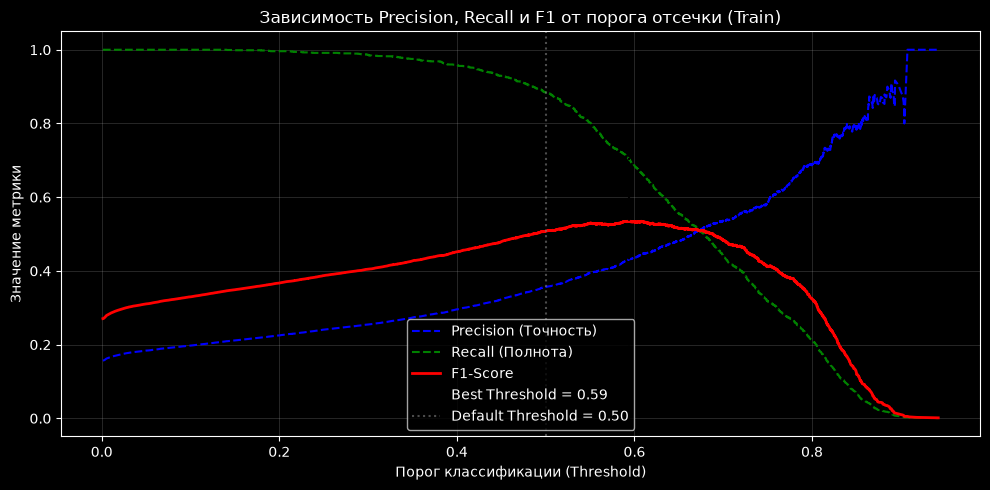

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, classification_report

# Выбираем лучшую модель (например, HistGradientBoosting или LightGBM)
chosen_model = gb  # или lgb

# 1. Получаем предсказанные вероятности для Train и Test
prob_train = chosen_model.predict_proba(X_train)[:, 1]
prob_test = chosen_model.predict_proba(X_test)[:, 1]

# 2. Вычисляем Precision, Recall и пороги на ОБУЧАЮЩЕЙ выборке
precisions, recalls, thresholds = precision_recall_curve(y_train, prob_train)

# Вычисляем F1-score для каждого порога
# thresholds имеет длину на 1 меньше, чем precisions и recalls
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Находим индекс максимального F1 и соответствующий порог
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1_train = f1_scores[best_idx]

print(f"=== Оптимизация порога (на Train) ===")
print(f"Оптимальный порог: {best_threshold:.3f}")
print(f"Максимальный Train F1: {best_f1_train:.3f}")

# 3. Оцениваем результат на ТЕСТОВОЙ выборке
# Дефолтный порог 0.5
y_test_pred_default = (prob_test >= 0.5).astype(int)
f1_test_default = f1_score(y_test, y_test_pred_default)

# Новый оптимальный порог
y_test_pred_tuned = (prob_test >= best_threshold).astype(int)
f1_test_tuned = f1_score(y_test, y_test_pred_tuned)

print(f"\n=== Сравнение на отложенном Test ===")
print(f"Test F1 при дефолтном пороге (0.500):    {f1_test_default:.3f}")
print(f"Test F1 при оптимальном пороге ({best_threshold:.3f}): {f1_test_tuned:.3f}")
print(f"Прирост F1: {f1_test_tuned - f1_test_default:+.3f}")

print("\n--- Подробный отчет для оптимального порога на Test ---")
print(classification_report(y_test, y_test_pred_tuned, target_names=['No Revenue', 'Revenue']))

# 4. Визуализация зависимости метрик от порога
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label='Precision (Точность)', color='blue', linestyle='--')
plt.plot(thresholds, recalls[:-1], label='Recall (Полнота)', color='green', linestyle='--')
plt.plot(thresholds, f1_scores, label='F1-Score', color='red', linewidth=2)

plt.axvline(x=best_threshold, color='black', linestyle=':', label=f'Best Threshold = {best_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.6, label='Default Threshold = 0.50')

plt.title('Зависимость Precision, Recall и F1 от порога отсечки (Train)')
plt.xlabel('Порог классификации (Threshold)')
plt.ylabel('Значение метрики')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



LightGBM - лучше всего выбрать для продакшена он показал наилучшие результаты так же он занимает меньше ресурсов чем случайный лес

F1 score - лучшей здесь показатель
конечно порог отсечения нужно редактировать в зависимости от цeyы ошибки и цены пропуска клиента

PR-AUC - вторая по важности метрика, это f1 без отсечения



PageValues - не возможно использовать во время посещения сайта

1 так как метрика появляется только после того пользователь совершил покупку, тоесть признак не доступен во время посещения - это и есть data leaks

2 так же мы не можем обучать модель на pageValues так как модель
 перестанет искать скрытые закономерности так как признак PageValues очень силён(PageValues > 0 = Покупка)


Обходной путь использовать за прошлые месяцы средний PageValues для страниц и как то можно обучить тогда
